## Домашнее задание № 1 (Макс. 10 баллов)

В данной домашней работе мы познакомимся на практике с пройденными темами, включающими в себя статистику, проверку гипотез и A/B тестирование.

### Задача 1 (2 балла)

**(1 Балл)** Рассчитайте среднее, стандартное отклонение и медиану по 1000 случайных выборок, порождённых нормальным распределением с $\mu = 5$ и $\sigma^2 = 4$, состоящих из 100 элементов. Постройте распределение полученных метрик.

Проверим размерность: (1000, 100)
Среднее средних: 4.9978
Среднее std:     1.9900
Среднее медиан:  5.0032


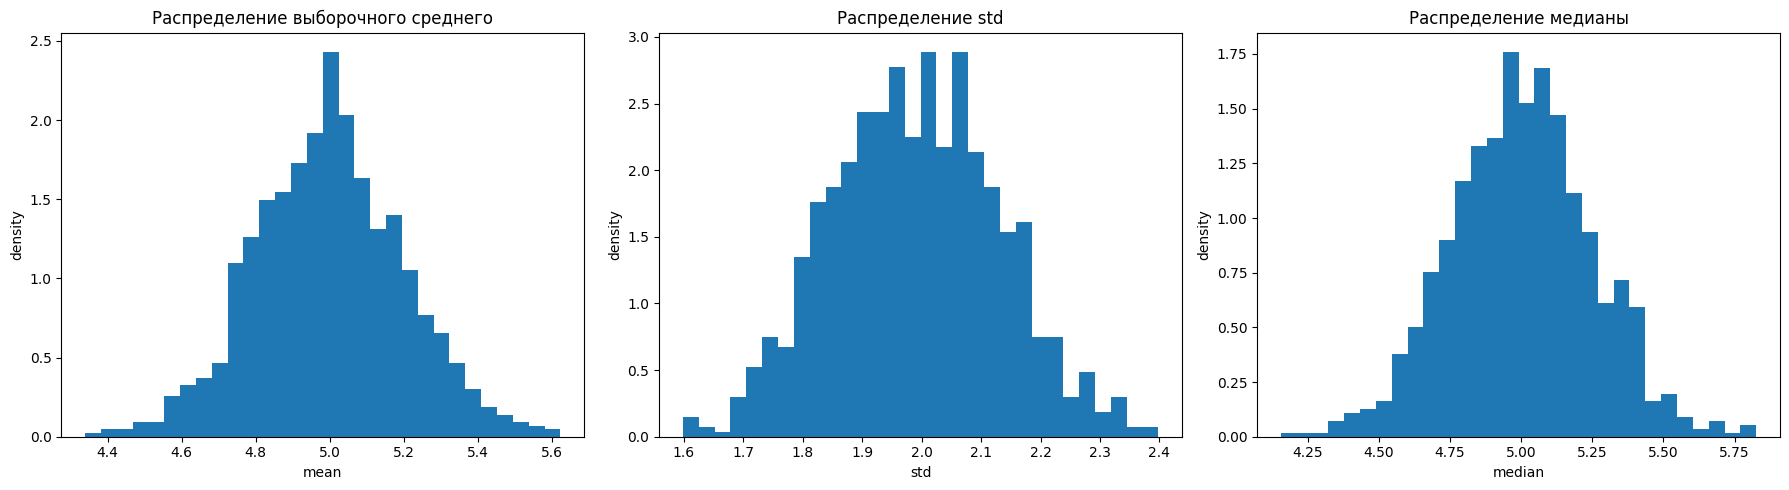

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
from tqdm import tqdm

def calc_stat_random_sample(mu, sigma, size):
    mean = np.mean(sample)
    std = np.std(sample)
    median = np.median(sample)
    return(mean, std, median)

mu = 5
sigma = 2
sample_size = 100
n_samples = 1000
samples = sps.norm.rvs(loc=mu, scale=sigma, size=(n_samples, sample_size))
print('Проверим размерность:', samples.shape)

# расчет средних, стандартных отклонений и медиан
means = []
stds = []
medians = []

for sample in samples:
    mean, std, median = calc_stat_random_sample(mu, sigma, sample)
    means.append(mean)
    stds.append(std)
    medians.append(median)

means = np.array(means)
stds = np.array(stds)
medians = np.array(medians)
print(f"Среднее средних: {means.mean():.4f}")
print(f"Среднее std:     {stds.mean():.4f}")
print(f"Среднее медиан:  {medians.mean():.4f}")

# построение распределений
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(means, bins=30, density=True)
axes[0].set_title("Распределение выборочного среднего")
axes[0].set_xlabel("mean")
axes[0].set_ylabel("density")

axes[1].hist(stds, bins=30, density=True)
axes[1].set_title("Распределение std")
axes[1].set_xlabel("std")
axes[1].set_ylabel("density")

axes[2].hist(medians, bins=30, density=True)
axes[2].set_title("Распределение медианы")
axes[2].set_xlabel("median")
axes[2].set_ylabel("density")

plt.tight_layout()
plt.show()


**(1 Балл)** Какому распределению принадлежит распределение средних? Почему?

In [59]:
# Распределение средних - нормальное, в силу ЦПТ. Но давайте проверим это с помощью Колмогорова-Смирнова на нормальность
expected_mu = mu
expected_sigma = sigma / np.sqrt(sample_size)

# Тест KS
ks_statistic, ks_pvalue = sps.kstest(means, 'norm', args=(expected_mu, expected_sigma))

print(f"  - Математическое ожидание: {expected_mu}")
print(f"  - Стандартное отклонение: {expected_sigma:.4f}")
print(f"Статистика KS (D): {ks_statistic:.6f}")
print(f"p-value: {ks_pvalue:.6f}")

alpha = 0.05
if ks_pvalue > alpha:
    print(f"p-value ({ks_pvalue:.6f}) > alpha ({alpha})")
    print("Не отвергаем H₀: распределение СООТВЕТСТВУЕТ нормальному.")
else:
    print(f"p-value ({ks_pvalue:.6f}) <= alpha ({alpha})")
    print("Отвергаем H₀: распределение НЕ соответствует нормальному.")

  - Математическое ожидание: 5
  - Стандартное отклонение: 0.2000
Статистика KS (D): 0.028640
p-value: 0.377852
p-value (0.377852) > alpha (0.05)
Не отвергаем H₀: распределение СООТВЕТСТВУЕТ нормальному.


In [57]:
ks_stat, p_value = sps.kstest(
    means,
    "norm",
    args=(5, 0.2)
)

print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value = {p_value:.4f}")

KS statistic = 0.4004
p-value = 0.0000


### Задача 2 (2 балла):

Оцените значение $\hat{\mu}$ параметра $\mu$ **(1 балл)** для нормального распределения $\mathscr{N}(\mu,1)$ используя метод максимального правдоподобия.

Справка: функция плотности распределения для нормального распределения имеет вид:
$$
    f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \text{e}^{-\frac{(x - \mu)^2}{2 \sigma^2}}
$$

Пусть у нас есть одно наблюдение $X_i $

Плотность нормального распределения:

 $$ f(x_i \mid \mu) = \frac{1}{\sqrt{2\pi}} e^{-\frac{(x_i - \mu)^2}{2}} $$

Получаем функцию правдоподобия
$$
L(\mu) = \prod_{i=1}^n f(x_i \mid \mu)
$$


Мы хотим найти такое  $\mu \$, при котором эта функция максимальна:
$$
\hat{\mu} = \arg\max_\mu L(\mu)
$$


Произведение из $ n $ плотностей неудобно дифференцировать:
$$
L(\mu) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi}} e^{-\frac{(x_i - \mu)^2}{2}}
$$

Поэтому берём логарифм:
$$
\ell(\mu) = \ln L(\mu)
$$

Получаем:
$$
\ell(\mu) = -\frac{n}{2} \ln(2\pi) - \frac{1}{2} \sum_{i=1}^n (x_i - \mu)^2
$$

Теперь нужно максимизировать эту функцию.
Поскольку первый член от $ \mu $ не зависит, фактически мы максимизируем:
$$
-\frac{1}{2} \sum_{i=1}^n (x_i - \mu)^2
$$

А это то же самое, что минимизировать:
$$
\sum_{i=1}^n (x_i - \mu)^2
$$

Дифференцируем и приравниваем к нулю:
$$
\frac{d\ell}{d\mu} = \sum_{i=1}^n (x_i - \mu) = 0
$$

Раскрываем:
$$
\sum_{i=1}^n x_i - n\mu = 0.
$$

Следовательно:
$$
n\mu = \sum_{i=1}^n x_i
$$
и наконец:
$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i = \bar{X}.
$$

То есть MLE-оценка $ \mu $ для $ N(\mu, 1) $ — это обычное выборочное среднее.


Сгенерируйте 1000 выборок размером 1000 наблюдений из нормального распределения с $\mu = 5, \sigma^2 = 1$, постройте распределение разности $\mu - \hat{\mu}$ и найдите среднее этой разности в зависимости от числа выборок **(1 балл)**.

Среднее ошибок: -0.0006
Стандартное отклонение ошибок: 0.0321


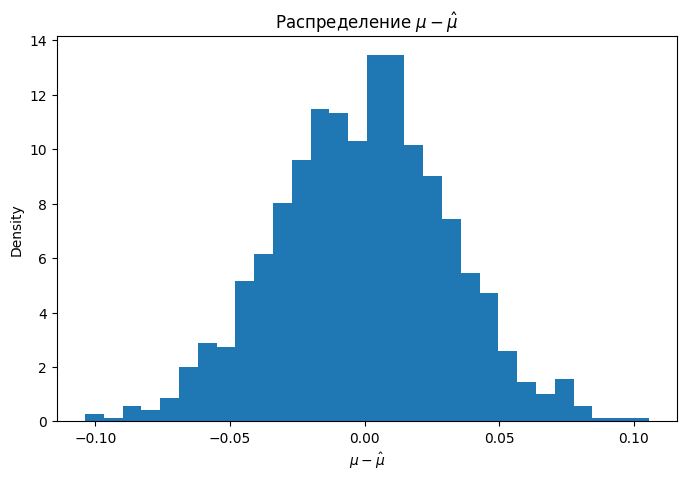

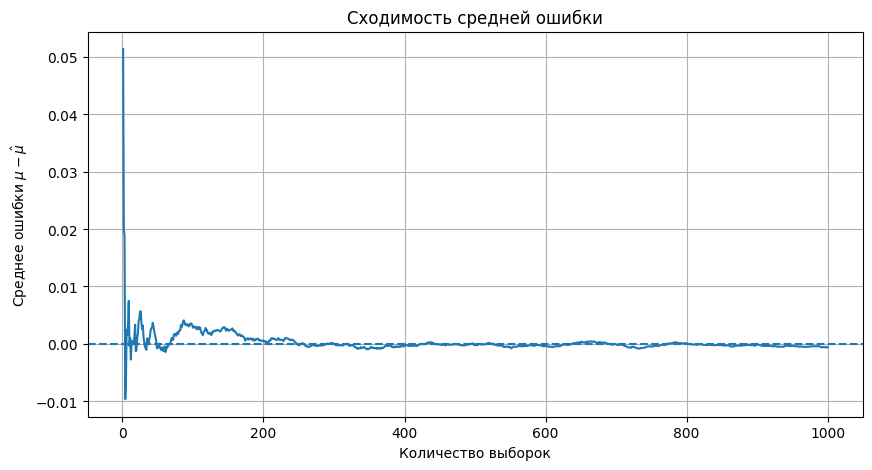

In [25]:
samples = sps.norm.rvs(loc=5, scale=1, size=(1000,1000))
mu_hats = samples.mean(axis=1) # так как выяснили выше, что оценка MLE - это просто выборочное среднее
errors = mu - mu_hats

print(f"Среднее ошибок: {errors.mean():.4f}")
print(f"Стандартное отклонение ошибок: {errors.std():.4f}")

# распределение ошибки
plt.figure(figsize=(8, 5))
plt.hist(
    errors,
    bins=30,
    density=True
)

plt.xlabel(r"$\mu - \hat{\mu}$")
plt.ylabel("Density")
plt.title(r"Распределение $\mu - \hat{\mu}$")
plt.show()

# среднее разности в зависимости от числа выборок
cumulative_mean_error = np.cumsum(errors) / np.arange(1, 1001)

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1,1001),
    cumulative_mean_error
)
plt.axhline(
    0,
    linestyle="--"
)
plt.xlabel("Количество выборок")
plt.ylabel(r"Среднее ошибки $\mu - \hat{\mu}$")
plt.title("Сходимость средней ошибки")
plt.grid()
plt.show()

### Задача 3 (2 балла)

**(1 балл)** Пусть известно, что выборка в n наблюдений порождена распределением Бернулли ~Bernoulli(p), пусть среднее значение по выборке равно $\hat{p}$. Постройте формулу 95% доверительного интервал для среднего

Для распределения Бернулли:

1. Оценка параметра: $\hat{p} = \bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$
2. Стандартная ошибка оценки: $SE(\hat{p}) = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$
3. По центральной предельной теореме (ЦПТ), при достаточно большом $n$:
   $$\frac{\hat{p} - p}{SE(\hat{p})} \xrightarrow{} N(0,1)$$

Следовательно, 95% доверительный интервал для $p$ имеет вид:

$$\left[\hat{p} - 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}, \quad \hat{p} + 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}\right]$$

где $1.96$ — это 97.5-й процентиль стандартного нормального распределения.

**(1 балл)** Постройте 95% доверительный интервал на среднее в представленной выборке, используя бутстрап и сравните с теоретическим значением

In [31]:
X = sps.bernoulli.rvs(0.2, size = 10000, random_state=42)
alpha = 0.05
p_hat = np.mean(X)
n = len(X)
se = np.sqrt(p_hat * (1 - p_hat) / n)

# теоретически
z_critical = sps.norm.ppf(1 - alpha/2)
ci_theoretical_lower = p_hat - z_critical * se
ci_theoretical_upper = p_hat + z_critical * se
print(f"p̂ = {p_hat:.5f}")
print(f"SE = {se:.5f}")
print(f"95% ДИ = [{ci_theoretical_lower:.5f}, {ci_theoretical_upper:.5f}]")

p̂ = 0.19620
SE = 0.00397
95% ДИ = [0.18842, 0.20398]


Бустрап 95% ДИ
Среднее бутстрап-средних = 0.19622
95% ДИ = [0.18810, 0.20400]
СРАВНЕНИЕ
Теоретический: [0.18842, 0.20398]
Бутстрап: [0.18810, 0.20400]
Ширина ДИ: теоретический = 0.01557, бутстрап = 0.01591


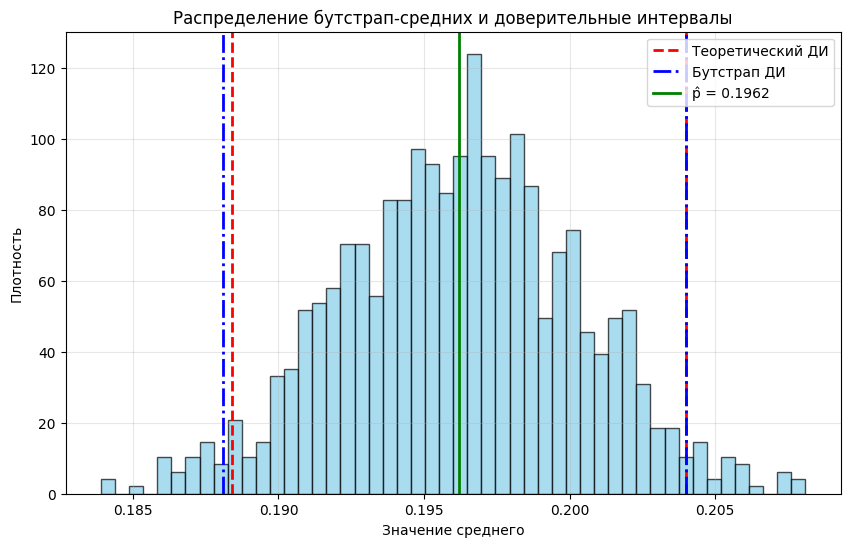

In [46]:
# бустрап
n_bootstrap = 1000
bootstrap_means = []

for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(X, size=len(X), replace=True)
    bootstrap_means.append(np.mean(bootstrap_sample))

bootstrap_means = np.array(bootstrap_means)
ci_bootstrap_lower = np.percentile(bootstrap_means, 2.5)
ci_bootstrap_upper = np.percentile(bootstrap_means, 97.5)

print("Бустрап 95% ДИ")
print(f"Среднее бутстрап-средних = {np.mean(bootstrap_means):.5f}")
print(f"95% ДИ = [{ci_bootstrap_lower:.5f}, {ci_bootstrap_upper:.5f}]")

print("СРАВНЕНИЕ")
print(f"Теоретический: [{ci_theoretical_lower:.5f}, {ci_theoretical_upper:.5f}]")
print(f"Бутстрап: [{ci_bootstrap_lower:.5f}, {ci_bootstrap_upper:.5f}]")
print(f"Ширина ДИ: теоретический = {ci_theoretical_upper - ci_theoretical_lower:.5f}, "
      f"бутстрап = {ci_bootstrap_upper - ci_bootstrap_lower:.5f}")


# для построения этого графика использовал ИИ
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(ci_theoretical_lower, color='red', linestyle='--', linewidth=2, label='Теоретический ДИ')
plt.axvline(ci_theoretical_upper, color='red', linestyle='--', linewidth=2)
plt.axvline(ci_bootstrap_lower, color='blue', linestyle='-.', linewidth=2, label='Бутстрап ДИ')
plt.axvline(ci_bootstrap_upper, color='blue', linestyle='-.', linewidth=2)
plt.axvline(p_hat, color='green', linestyle='-', linewidth=2, label=f'p̂ = {p_hat:.4f}')

plt.xlabel('Значение среднего')
plt.ylabel('Плотность')
plt.title('Распределение бутстрап-средних и доверительные интервалы')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Задача 4 (4 балла)

Основным критерием для тестирования гипотезы о равенстве средних является t-test. Он строится на том, что по ЦПТ практически для любой случайной величины средние будут распределены нормально.

В учебниках по статистике доказывается, что в силу этого для двух выборок, порождённых одинаково распределёнными независимыми случайными величинами с равным средним мы имеем асимпототику для выборочной t-статистики
$$
    T = \frac{\bar{x} - \bar{y}}{\sqrt{\frac{s_x^2}{n_1} + \frac{s_y^2}{n_2}}} \rightarrow t_{n_1 + n_2 - 2},
$$
где $\bar{x}, \bar{y}$ -- выборочные средние в выборках, $s_x^2, s_y^2$ -- выборочные дисперсии, $n_1, n_2$ -- размеры выборок, а $t_{n_1 + n_2 - 2}$ -- распределение Стьюдента с $n_1 + n_2 - 2$ степенями свободы.

**(1 балл)** Постройте плотность распределения Стьюдента с 1, 5, 10, 100 и 1000 степеней свободы, а также плотность стандартного нормального распределения

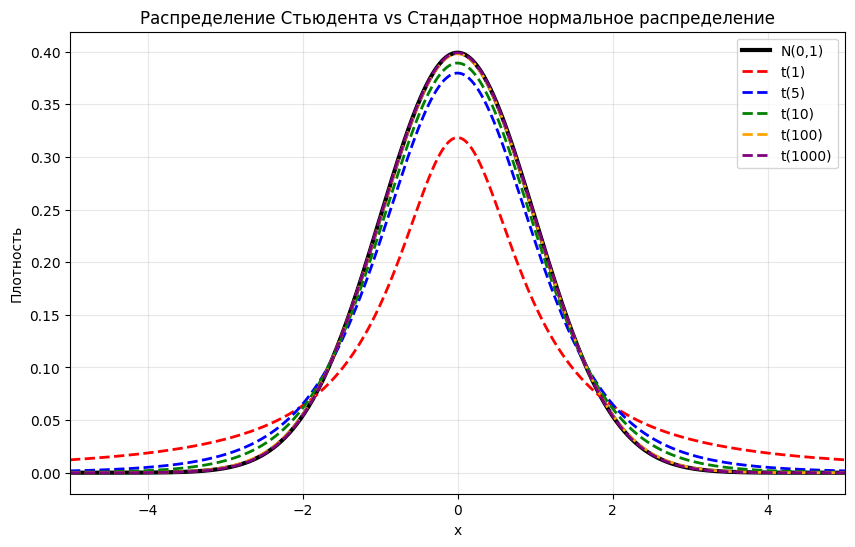

In [35]:
grid = np.arange(-10,10,0.01)

freedom_degrees = [1,5,10,100,1000]

plt.figure(figsize=(10, 6))

# Нормальное распределение
plt.plot(grid, sps.norm.pdf(grid, 0, 1),
         label='N(0,1)', linewidth=3, color='black', linestyle='-')

# Распределения Стьюдента
colors = ['red', 'blue', 'green', 'orange', 'purple']
for df, color in zip(freedom_degrees, colors):
    plt.plot(grid, sps.t.pdf(grid, df),
             label=f't({df})', linewidth=2, color=color, linestyle='--')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Распределение Стьюдента vs нормальное распределение')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-5, 5)
plt.show()

**(1 балл)** Пусть нам необходимо запустить A/B тест: в первой группе мы оставляем кнопку в банковском приложении в сером цвете, во втором -- красим её в жёлтый. Всего у нас в месяц в приложение заходит 1000 различных клиентов. Базовая конверсия в нажатие кнопки сейчас составляет 0.2. Бизнес постановил, что MDE = 5%, то есть значимым будет считаться изменение, при котором конверсия будет больше 0.21 или меньше 0.19. Хватит ли нам данных, чтобы замерить эффект за один месяц при уровне значимости $\alpha = 0.05$, если мы планируем поделить выборку пополам на тест и контроль?

In [41]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
p_control = 0.2
p_test = 0.19  # MDE = 5% от 0.2
n_control = 500
n_test = 500

# Для расчета мощности нам нужен эффект (Cohen's d)
# Для бинарных данных: d = (p1 - p2) / sqrt(p * (1-p))
# где p = (p1 + p2) / 2
p_pooled = (p_control + p_test) / 2
effect_size = (p_test - p_control) / np.sqrt(p_pooled * (1 - p_pooled))

# Расчет мощности
power_analysis = TTestIndPower()
power = power_analysis.power(
    effect_size=effect_size,
    nobs1=n_control,
    alpha=alpha,
    ratio=n_test / n_control,
    alternative='two-sided'
)

print(f"Контроль: p = {p_control}")
print(f"Тест: p = {p_test}")
print(f"MDE = {(p_test - p_control) / p_control * 100:.1f}%")
print(f"Размер выборки: n1 = {n_control}, n2 = {n_test}")
print(f"Effect size (Cohen's d) = {effect_size:.4f}")
print(f"Мощность (1 - β) = {power:.4f}")
print(f"β = {1 - power:.4f}")

if power >= 0.8:
    print(f"\n Мощность = {power:.4f} >= 0.8 — данных достаточно")
else:
    print(f"\n Мощность = {power:.4f} < 0.8 — данных НЕдостаточно")

Контроль: p = 0.2
Тест: p = 0.19
MDE = -5.0%
Размер выборки: n1 = 500, n2 = 500
Effect size (Cohen's d) = -0.0252
Мощность (1 - β) = 0.0684
β = 0.9316

 Мощность = 0.0684 < 0.8 — данных НЕ достаточно


**(1 балл)** Мы провели тест и получили следующие результаты:

In [38]:
X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000, random_state=42), sps.bernoulli.rvs(0.21, size = 1000, random_state=42)

Можем ли мы утверждать на уровне значимости $\alpha = 0.05$, что эффект имел место быть?

In [42]:
# проведем T-test
t_stat, p_value = sps.ttest_ind(X_1, X_2, equal_var=False, alternative='less') # less используем, так как ожидаем, что конверсия в тесте БОЛЬШЕ конверсии в контроле

print(f"Контроль: среднее = {np.mean(X_1):.4f}, n = {len(X_1)}")
print(f"Тест: среднее = {np.mean(X_2):.4f}, n = {len(X_2)}")
print(f"Разница = {np.mean(X_2) - np.mean(X_1):.4f}")
print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha})")
    print("Отвергаем H₀. Эффект статистически значим.")
else:
    print(f"p-value ({p_value:.4f}) >= alpha ({alpha})")
    print("Не отвергаем H₀. Нет статистически значимых доказательств эффекта.")

Контроль: среднее = 0.1990, n = 1000
Тест: среднее = 0.2110, n = 1000
Разница = 0.0120
t-статистика = -0.6644
p-value = 0.2533
p-value (0.2533) >= alpha (0.05)
Не отвергаем H₀. Нет статистически значимых доказательств эффекта.


**(1 балл)**

Что будет, если мы проведём 1000 таких тестов, "отпустив" random_state?

В какой доле случаев мы не задетектируем это существующее различие? Чему будет равна $\beta$?

In [51]:
n_simulations = 1000
alpha = 0.05
p_control_true = 0.2
p_test_true = 0.21
p_values = []


for i in range(n_simulations):
    control = sps.bernoulli.rvs(p_control_true, size=1000)
    test = sps.bernoulli.rvs(p_test_true, size=1000)
    _, p_val = sps.ttest_ind(control, test, equal_var=False, alternative='less')
    p_values.append(p_val)

p_values = np.array(p_values)
rejected = p_values < alpha  # True, если отвергли H0
power_empirical = np.mean(rejected)  # доля тестов, где обнаружили эффект
beta_empirical = 1 - power_empirical  # доля тестов, где НЕ обнаружили эффект

print(f"Доля тестов, где обнаружили эффект (мощность): {power_empirical:.4f}")
print(f"Доля тестов, где НЕ обнаружили эффект (β): {beta_empirical:.4f}")

Доля тестов, где обнаружили эффект (мощность): 0.1350
Доля тестов, где НЕ обнаружили эффект (β): 0.8650


А если различий не будет (при проведении 1000 A/A-тестов)? Как будет распределено p-value в этом случае?

In [52]:
p_values_aa = []

for _ in range(n_simulations):
    control = sps.bernoulli.rvs(0.2, size=1000)
    test = sps.bernoulli.rvs(0.2, size=1000)  # те же параметры!
    _, p_val = sps.ttest_ind(control, test, equal_var=False)
    p_values_aa.append(p_val)

p_values_aa = np.array(p_values_aa)
false_positives = np.mean(p_values_aa < alpha)

print(f"Доля ложноположительных результатов: {false_positives:.4f}")
print(f"Ожидаемое значение: {alpha:.4f} (уровень значимости)")

Доля ложноположительных результатов: 0.0460
Ожидаемое значение: 0.0500 (уровень значимости)


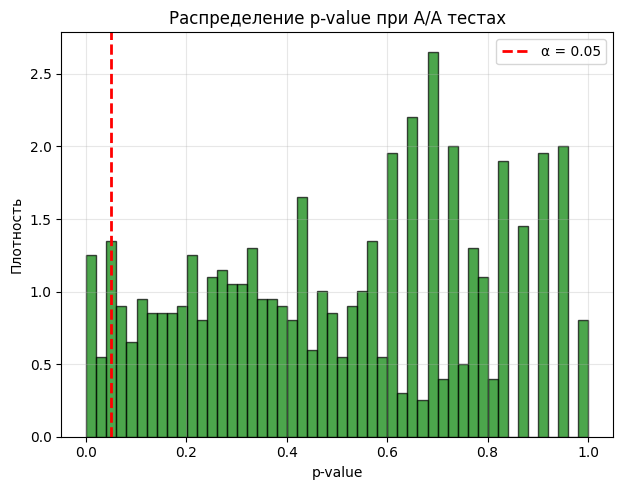

In [55]:
plt.figure(figsize=(12, 5))

# Гистограмма p-value
plt.subplot(1, 2, 1)
plt.hist(p_values_aa, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
plt.axvline(alpha, color='red', linestyle='--', linewidth=2, label='α = 0.05')
plt.xlabel('p-value')
plt.ylabel('Плотность')
plt.title('Распределение p-value при A/A тестах')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()